# ExoHabitAI
## Data Preprocessing Code File

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
project_root = os.path.dirname(os.getcwd())

file_path = os.path.join(
    project_root,
    "data",
    "raw",
    "PS_2026.02.13_04.47.45.csv"
)

output_path = os.path.join(
    project_root,
    "data",
    "preprocessed",
    "preprocessed.csv"
)

file_path

'd:\\Desktop\\B13-ExoHabitAI\\data\\raw\\PS_2026.02.13_04.47.45.csv'

## 1. Load Raw Dataset
This step loads the NASA exoplanet dataset and prepares it for preprocessing.

In [3]:
print("🚀 Starting Production-Grade Preprocessing Pipeline...\n")

try:
    df = pd.read_csv(file_path, comment="#", low_memory=False)
    print(f"✅ Raw data loaded. Shape: {df.shape}")
except FileNotFoundError:
    print(f"❌ File not found: {file_path}")
    df = None

🚀 Starting Production-Grade Preprocessing Pipeline...

✅ Raw data loaded. Shape: (39386, 289)


## 2. Filter Default Parameters
Keeping only scientifically validated default entries.

In [4]:
if df is not None and "default_flag" in df.columns:
    df = df[df["default_flag"] == 1].copy()
    print(f"✅ Filtered default_flag = 1. Shape: {df.shape}")

✅ Filtered default_flag = 1. Shape: (6107, 289)


## 3. Select Required Features
Only scientifically relevant planetary and stellar attributes are retained.

In [5]:
required_columns = {
    'pl_name': 'Planet_Name',
    'pl_rade': 'Planet_Radius',
    'pl_bmasse': 'Planet_Mass',
    'pl_orbper': 'Orbital_Period',
    'pl_orbsmax': 'Semi_Major_Axis',
    'pl_eqt': 'Equilibrium_Temp',
    'pl_dens': 'Planet_Density',
    'st_teff': 'Stellar_Temp',
    'st_lum': 'Stellar_Luminosity',
    'st_met': 'Stellar_Metallicity',
    'st_spectype': 'Stellar_Type'
}

available_cols = [c for c in required_columns if c in df.columns]
df = df[available_cols].rename(columns=required_columns).copy()

df.dropna(how="all", inplace=True)

print(f"✅ Selected features. Shape: {df.shape}")

✅ Selected features. Shape: (6107, 11)


## 4. Data Quality Assessment
Checking duplicates, missing values, and statistical summary.

In [6]:
print("Duplicates:", df.duplicated().sum())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Duplicates: 0

Missing Values:
 Planet_Name               0
Planet_Radius          1564
Planet_Mass            3104
Orbital_Period          346
Semi_Major_Axis        2309
Equilibrium_Temp       4430
Planet_Density         4950
Stellar_Temp            711
Stellar_Luminosity     4646
Stellar_Metallicity    1792
Stellar_Type           4788
dtype: int64

Summary Statistics:
        Planet_Radius  Planet_Mass  Orbital_Period  Semi_Major_Axis  \
count    4543.000000  3003.000000    5.761000e+03      3798.000000   
mean        4.449179   768.423499    4.495610e+03        21.803172   
std         4.957719  1500.779602    1.639150e+05       414.877616   
min         0.309800     0.020000    9.070629e-02         0.004400   
25%         1.620000    12.150000    4.360156e+00         0.054000   
50%         2.430000   171.000000    1.113125e+01         0.115050   
75%         4.037617   696.681616    3.954500e+01         0.801500   
max        87.205870  9534.852210    8.040000e+06     19000.00000

### Missing value heatmap

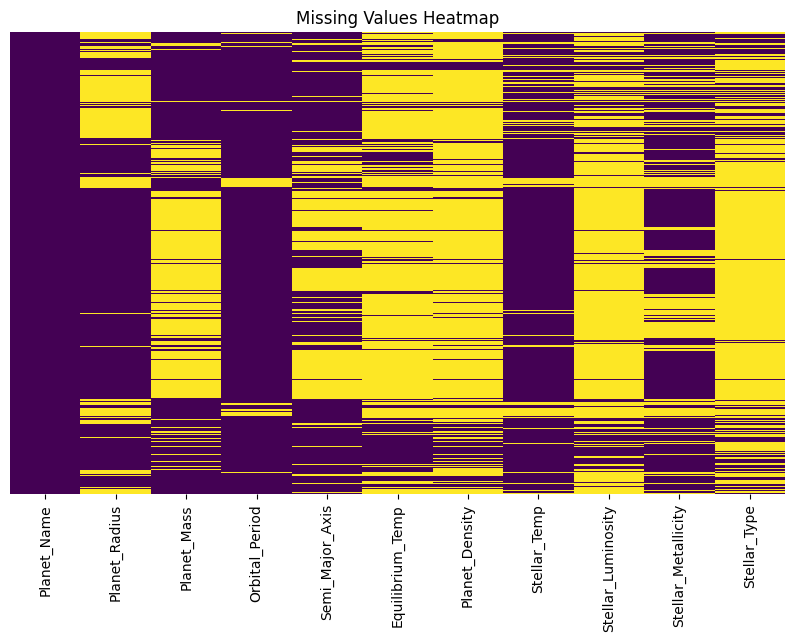

In [7]:
# Create full path to project-level reports folder
report_path = os.path.join(project_root, "reports")
os.makedirs(report_path, exist_ok=True)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap")

# Save to project-level reports folder
plt.savefig(os.path.join(report_path, "missing_values_heatmap.png"))

plt.show()   # <-- This displays it in notebook

## 5. REMOVE PHYSICALLY IMPOSSIBLE VALUES

In [8]:
df = df[
    (df["Planet_Radius"] > 0) &
    (df["Planet_Mass"] > 0) &
    (df["Equilibrium_Temp"] > 0) &
    (df["Equilibrium_Temp"] < 5000)
].copy()

print(f"✅ Physically invalid values removed. Shape: {df.shape}")

✅ Physically invalid values removed. Shape: (1057, 11)


## 6. HANDLE MISSING DATA

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = ["Stellar_Type"] if "Stellar_Type" in df.columns else []

# Numeric
df[numerical_cols] = df[numerical_cols].apply(
    lambda x: x.fillna(x.median())
)

# Categorical
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Missing values handled correctly.")

✅ Missing values handled correctly.


## 7. OUTLIER DETECTION (Z-SCORE + IQR)

In [10]:
for col in numerical_cols:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    df = df[z < 3]

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("✅ Outliers handled.")

✅ Outliers handled.


## 8. UNIT STANDARDIZATION

In [11]:
df["Stellar_Luminosity"] = 10 ** df["Stellar_Luminosity"]
print("✅ Units standardized.")

✅ Units standardized.


## 9. FEATURE ENGINEERING

In [12]:
flux = df["Stellar_Luminosity"] / (df["Semi_Major_Axis"]**2 + 1e-6)

R_earth, T_earth, S_earth = 1.0, 288.0, 1.0

h_r = 1 - abs((df["Planet_Radius"] - R_earth) /
              (df["Planet_Radius"] + R_earth))

h_t = 1 - abs((df["Equilibrium_Temp"] - T_earth) /
              (df["Equilibrium_Temp"] + T_earth))

h_s = 1 - abs((flux - S_earth) / (flux + S_earth))

df["Habitability_Score_Index"] = (h_r * h_t * h_s) ** (1/3)

df["Stellar_Compatibility_Index"] = np.exp(
    -0.5 * ((df["Stellar_Temp"] - 5778) / 1500) ** 2
)

P_yr = df["Orbital_Period"] / 365.25
df["Orbital_Stability_Factor"] = np.abs(
    np.log10((df["Semi_Major_Axis"]**3 + 1e-6) / (P_yr**2 + 1e-6))
)

print("✅ Feature engineering complete.")

✅ Feature engineering complete.


## 10. CATEGORICAL ENCODING (One-Hot)

In [13]:
if "Stellar_Type" in df.columns:
    df["Star_Class"] = df["Stellar_Type"].astype(str).str[0].str.upper()
    valid_classes = ["O", "B", "A", "F", "G", "K", "M"]
    df["Star_Class"] = df["Star_Class"].apply(
        lambda x: x if x in valid_classes else "Other"
    )
    df = pd.get_dummies(df, columns=["Star_Class"], prefix="StarType")
    df.drop(columns=["Stellar_Type"], inplace=True)

print("✅ Categorical encoding complete.")

✅ Categorical encoding complete.


## 11. TARGET CREATION (Binary)

In [14]:
is_rocky = (df["Planet_Radius"] <= 1.6) | (df["Planet_Mass"] <= 10)
is_temp = (df["Equilibrium_Temp"] >= 180) & (df["Equilibrium_Temp"] <= 320)
is_flux = (flux >= 0.25) & (flux <= 2.2)

# Create balanced target using Habitability Score
threshold = df["Habitability_Score_Index"].median()

df["Target_Habitable"] = np.where(
    df["Habitability_Score_Index"] >= threshold,
    1,
    0
)

print("\nTarget Distribution:")
print(df["Target_Habitable"].value_counts(normalize=True))


Target Distribution:
Target_Habitable
1    0.500505
0    0.499495
Name: proportion, dtype: float64


## 12. SAVE DATASET

In [15]:
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

print(f"\n💾 Preprocessed dataset saved to: {output_path}")
print("🎉 Preprocessing Completed Successfully!")


💾 Preprocessed dataset saved to: d:\Desktop\B13-ExoHabitAI\data\preprocessed\preprocessed.csv
🎉 Preprocessing Completed Successfully!
